### Importación de librerías y configuración de rutas

In [1]:
import os
import random
import glob
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, to_np

# Ruta al directorio donde se guardaron las simulaciones (ajusta si es necesario)
output_dir = "/home/jorge.gacitua/salidas/Sensitivity_Experiments/Outputs"

# Buscar todos los archivos NetCDF generados
all_files = glob.glob(os.path.join(output_dir, "run_*", "wrfout_*.nc"))
all_files.sort()

print(f"Total de simulaciones encontradas: {len(all_files)}")

Total de simulaciones encontradas: 5


### Selección aleatoria de miembros

In [2]:
# Seleccionar 4 miembros al azar para la verificación
num_samples = 4
if len(all_files) >= num_samples:
    sampled_files = random.sample(all_files, num_samples)
else:
    sampled_files = all_files

print("Miembros seleccionados para visualización:")
for f in sampled_files:
    print(f" - {os.path.basename(f)}")

Miembros seleccionados para visualización:
 - wrfout_002.nc
 - wrfout_004.nc
 - wrfout_003.nc
 - wrfout_000.nc


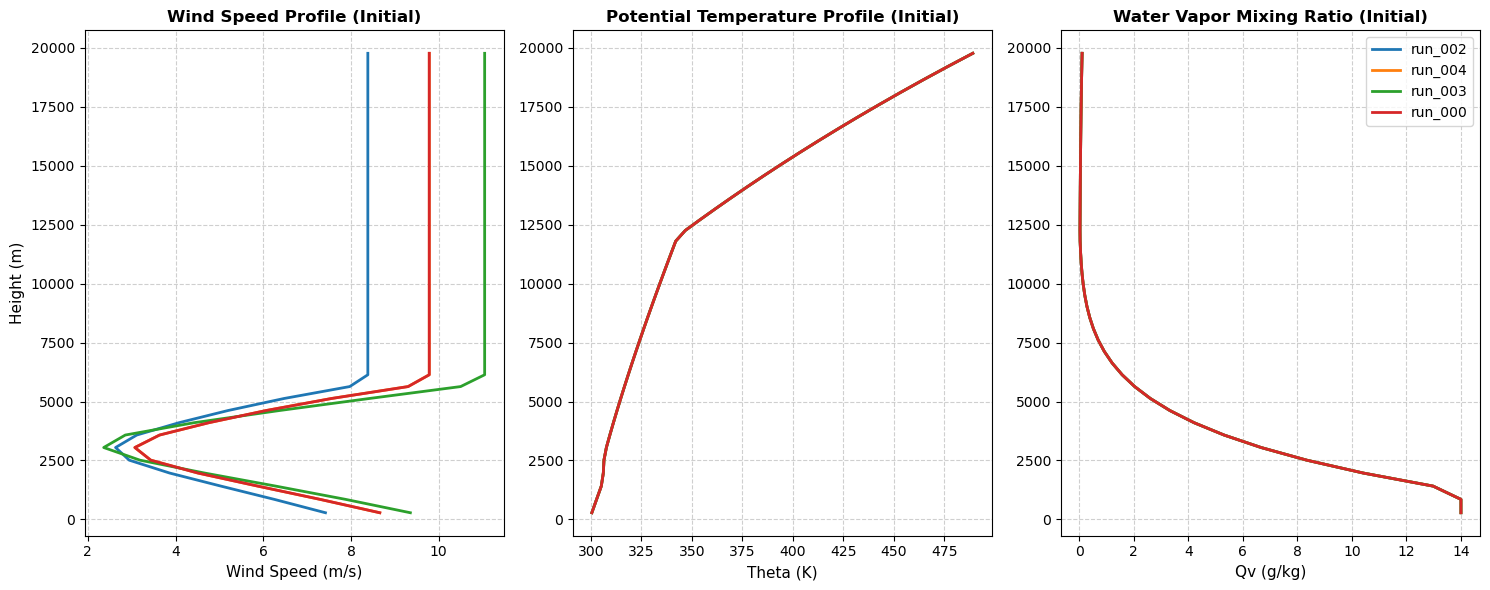

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, file_path in enumerate(sampled_files):
    ncfile = Dataset(file_path)
    run_name = os.path.basename(os.path.dirname(file_path))
    
    # Extraer variables en el tiempo inicial (t=0)
    z = to_np(getvar(ncfile, "z", timeidx=0))
    u = to_np(getvar(ncfile, "ua", units="ms-1", timeidx=0))
    v = to_np(getvar(ncfile, "va", units="ms-1", timeidx=0))
    theta = to_np(getvar(ncfile, "theta", units="K", timeidx=0))
    qv = to_np(getvar(ncfile, "QVAPOR", timeidx=0)) * 1000.0 # Convertir a g/kg
    
    # Calcular magnitud del viento horizontal
    wspd = np.sqrt(u**2 + v**2)
    
    # Encontrar el centro del dominio
    nz, ny, nx = z.shape
    cy, cx = ny // 2, nx // 2
    
    # Extraer perfiles promediando sobre los 5 vecinos inmediatos (cruz central)
    # Esto aporta precisión formal evitando sesgos de un único punto de grilla
    def get_5_point_avg(var):
        return (var[:, cy, cx] + 
                var[:, cy+1, cx] + 
                var[:, cy-1, cx] + 
                var[:, cy, cx+1] + 
                var[:, cy, cx-1]) / 5.0

    z_prof = get_5_point_avg(z)
    wspd_prof = get_5_point_avg(wspd)
    theta_prof = get_5_point_avg(theta)
    qv_prof = get_5_point_avg(qv)
    
    # Panel 1: Velocidad del Viento
    axes[0].plot(wspd_prof, z_prof, label=run_name, color=colors[idx], linewidth=2)
    
    # Panel 2: Temperatura Potencial (Estabilidad)
    axes[1].plot(theta_prof, z_prof, label=run_name, color=colors[idx], linewidth=2)
    
    # Panel 3: Humedad (Vapor de agua)
    axes[2].plot(qv_prof, z_prof, label=run_name, color=colors[idx], linewidth=2)

# Formateo estético y formal de las gráficas
axes[0].set_title('Wind Speed Profile (Initial)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Wind Speed (m/s)', fontsize=11)
axes[0].set_ylabel('Height (m)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].set_title('Potential Temperature Profile (Initial)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Theta (K)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].set_title('Water Vapor Mixing Ratio (Initial)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Qv (g/kg)', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_639591/4126638941.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  contour = ax.contourf(to_np(mdbz), levels=levels, cmap=get_cmap("gist_ncar"), extend='max')


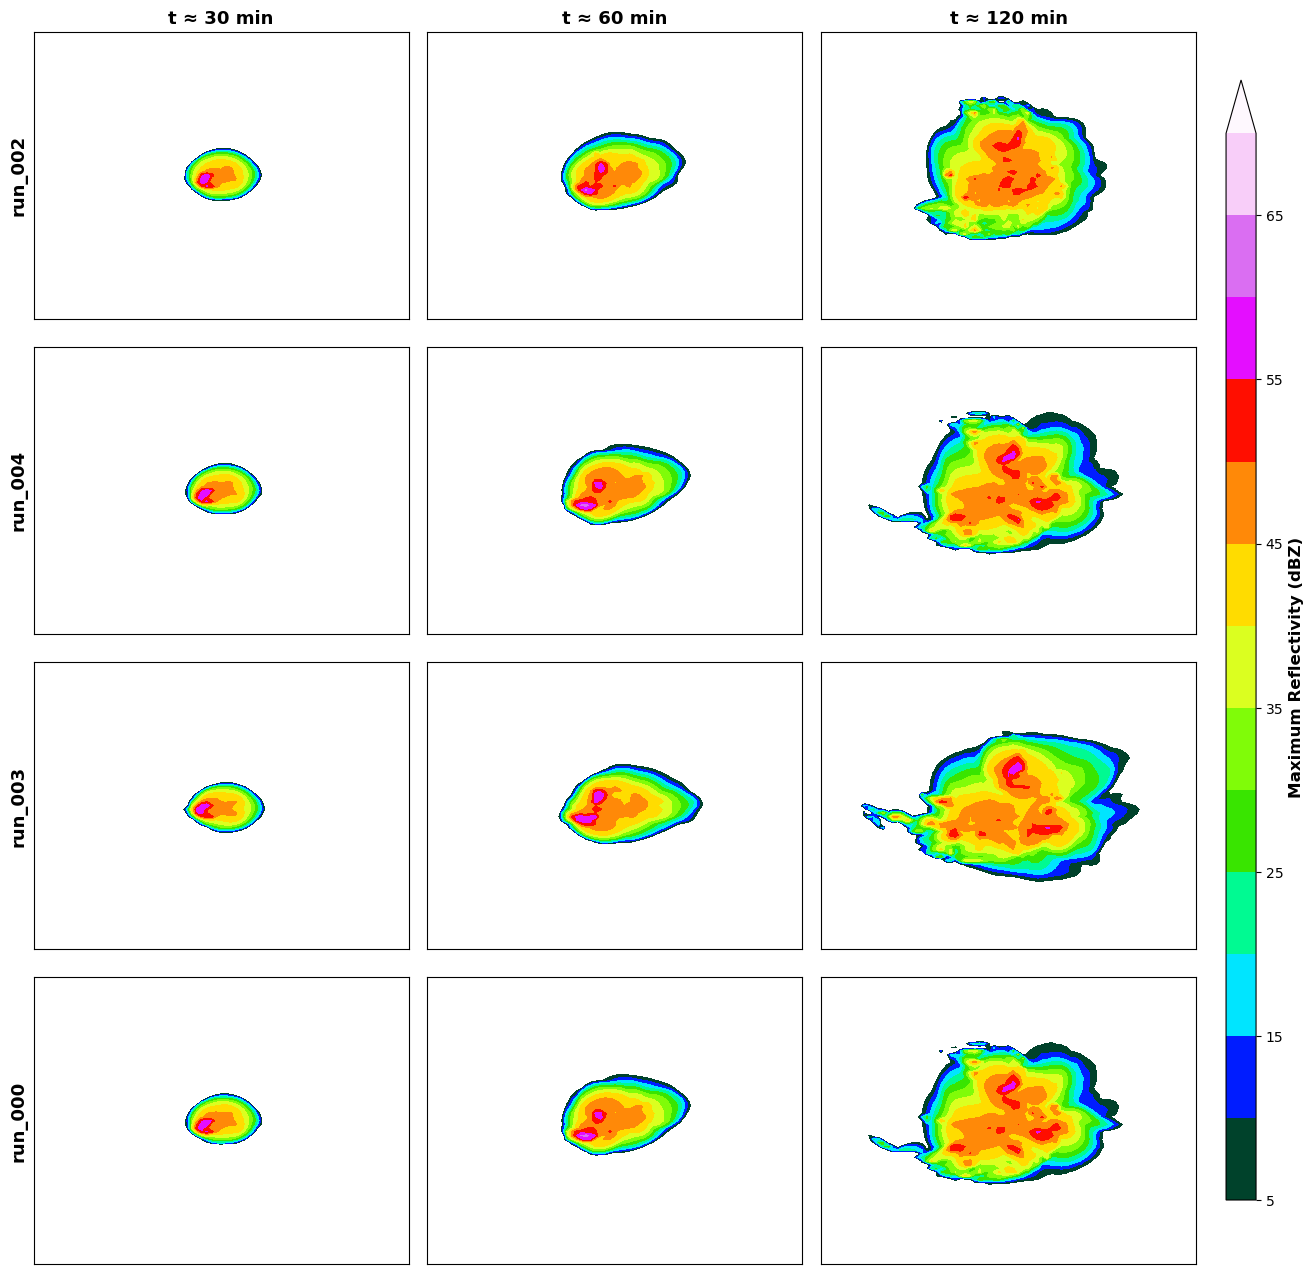

In [5]:
from matplotlib.cm import get_cmap
import wrf

# Tiempos objetivo en minutos
target_minutes = [30, 60, 120]
num_rows = len(sampled_files)

# Configurar la figura (matriz de N filas x 3 columnas)
fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 4 * num_rows))

for row_idx, file_path in enumerate(sampled_files):
    ncfile = Dataset(file_path)
    run_name = os.path.basename(os.path.dirname(file_path))
    
    # Extraer todos los tiempos de la simulación
    times = wrf.extract_times(ncfile, timeidx=wrf.ALL_TIMES)
    
    # Calcular los minutos transcurridos desde t=0
    if len(times) > 1:
        t0 = times[0]
        # Convertir la diferencia de tiempo a minutos exactos
        elapsed_mins = np.array([(t - t0) / np.timedelta64(1, 'm') for t in times])
    else:
        print(f"Advertencia: {run_name} solo tiene un tiempo guardado. Omite este miembro.")
        continue
        
    for col_idx, target_min in enumerate(target_minutes):
        # Manejo de índices si num_rows es 1 o mayor
        ax = axes[row_idx, col_idx] if num_rows > 1 else axes[col_idx]
        
        # Encontrar el índice de tiempo más cercano al objetivo (30, 60, 120)
        closest_idx = np.argmin(np.abs(elapsed_mins - target_min))
        actual_min = int(elapsed_mins[closest_idx])
        
        # Extraer Reflectividad Máxima (Composite Reflectivity)
        mdbz = wrf.getvar(ncfile, "mdbz", timeidx=closest_idx)
        
        # Graficar contornos (usando la paleta estándar de radar)
        levels = np.arange(5, 75, 5)
        contour = ax.contourf(to_np(mdbz), levels=levels, cmap=get_cmap("gist_ncar"), extend='max')
        
        # Títulos de columna (solo en la primera fila)
        if row_idx == 0:
            ax.set_title(f"t ≈ {actual_min} min", fontsize=13, fontweight='bold')
            
        # Etiquetas de fila (solo en la primera columna)
        if col_idx == 0:
            ax.set_ylabel(run_name, fontsize=13, fontweight='bold')
            
        # Limpiar los ejes x/y para enfocarse puramente en la estructura de la tormenta
        ax.set_xticks([])
        ax.set_yticks([])

# Agregar una barra de color global a la derecha
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(contour, cax=cbar_ax)
cbar.set_label("Maximum Reflectivity (dBZ)", fontsize=12, fontweight='bold')

plt.subplots_adjust(wspace=0.05, hspace=0.1, right=0.9)
plt.show()